In [ ]:
%pip install ipykernel

In [34]:
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
import albumentations as A
from collections import Counter


In [35]:
DATASET_PATH =  r"D:\physio_ai_project\exercise_dataset\image_dataset"

In [36]:
classes = [d for d in os.listdir(DATASET_PATH)
           if os.path.isdir(os.path.join(DATASET_PATH, d))]

print("Classes:", classes)
print("Number of classes:", len(classes))


Classes: ['push_up', 'sit_up', 'squat']
Number of classes: 3


In [37]:
video_count = {}
image_count = {}

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    videos = os.listdir(cls_path)
    video_count[cls] = len(videos)

    total_images = 0
    for v in videos:
        v_path = os.path.join(cls_path, v)
        total_images += len(os.listdir(v_path))
    image_count[cls] = total_images

print("Video count:", video_count)
print("Image count:", image_count)


Video count: {'push_up': 71, 'sit_up': 71, 'squat': 70}
Image count: {'push_up': 5019, 'sit_up': 5439, 'squat': 3747}


In [38]:
classes = [ 'push_up', 'sit_up', 'squat']

video_count = {
    
    'push_up': 70, 'sit_up': 70, 'squat': 68
}

image_count = {
    
    'push_up': 5019, 'sit_up': 5439, 'squat': 3747
}


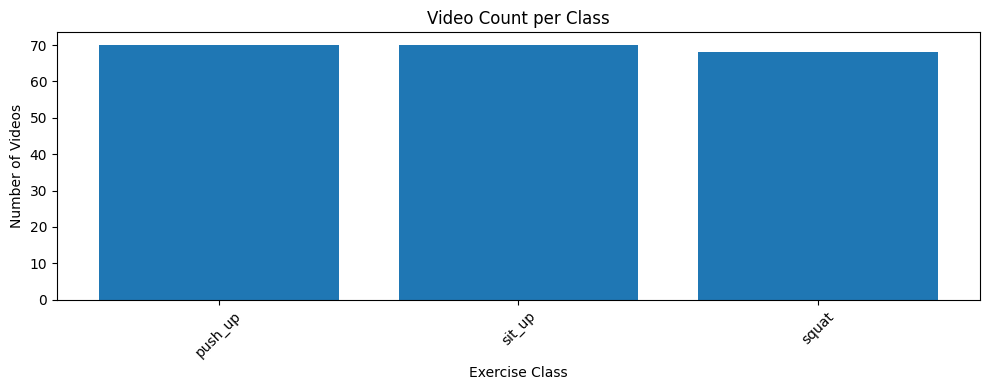

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(video_count.keys(), video_count.values())
plt.title("Video Count per Class")
plt.xlabel("Exercise Class")
plt.ylabel("Number of Videos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


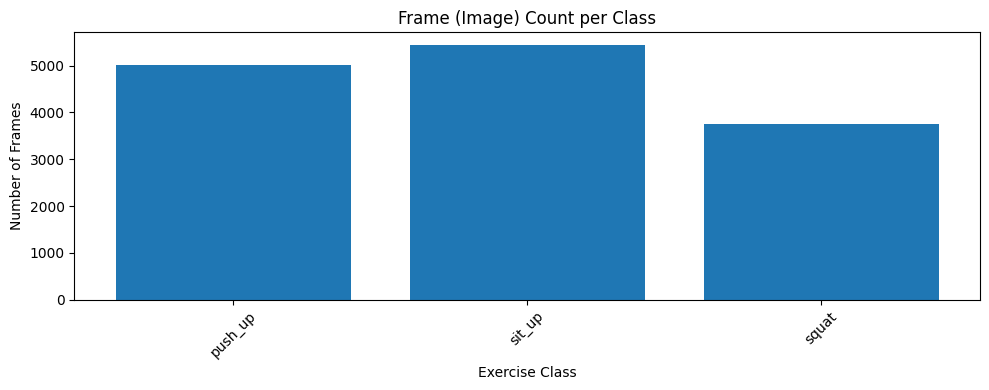

In [40]:
plt.figure(figsize=(10, 4))
plt.bar(image_count.keys(), image_count.values())
plt.title("Frame (Image) Count per Class")
plt.xlabel("Exercise Class")
plt.ylabel("Number of Frames")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


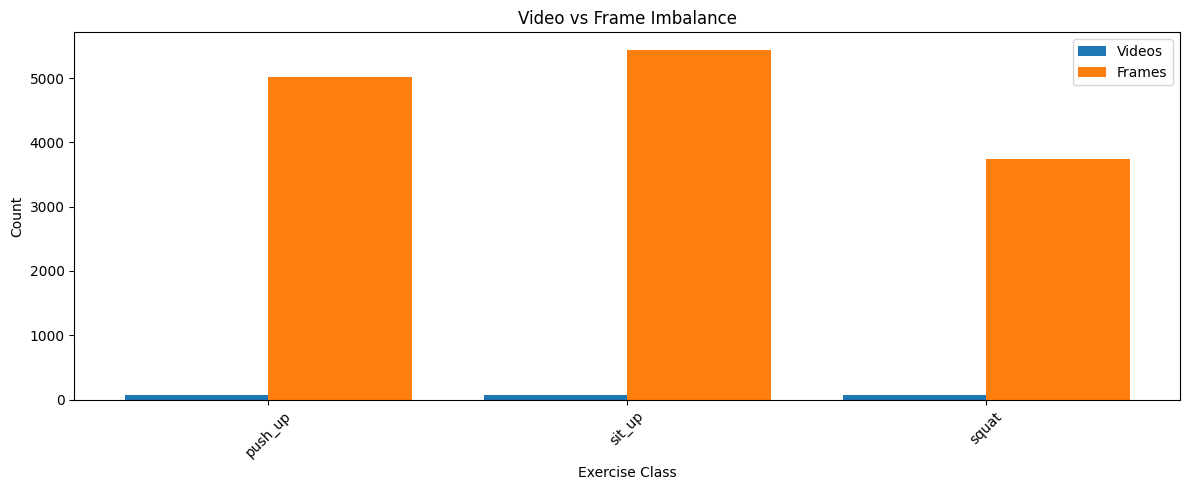

In [41]:
import numpy as np

x = np.arange(len(classes))
width = 0.4

video_vals = [video_count[c] for c in classes]
image_vals = [image_count[c] for c in classes]

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, video_vals, width, label="Videos")
plt.bar(x + width/2, image_vals, width, label="Frames")

plt.xticks(x, classes, rotation=45)
plt.xlabel("Exercise Class")
plt.ylabel("Count")
plt.title("Video vs Frame Imbalance")
plt.legend()
plt.tight_layout()
plt.show()


In [42]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp
import tensorflow as tf
import math

from sklearn.model_selection import train_test_split
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score, classification_report
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from tensorflow.keras.models import Sequential, Model

from tensorflow.keras.layers import (LSTM, Dense, Concatenate, Attention, Dropout, Softmax,
                                     Input, Flatten, Activation, Bidirectional, Permute, multiply, 
                                     ConvLSTM2D, MaxPooling3D, TimeDistributed, Conv2D, MaxPooling2D)

from scipy import stats

# disable some of the tf/keras training warnings 
os.environ['TF_CPP_MIN_LOG_LEVEL'] = "3"
tf.get_logger().setLevel("ERROR")
tf.autograph.set_verbosity(1)

# suppress untraced functions warning
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

In [43]:
print("Mediapipe version:", mp.__version__)

Mediapipe version: 0.10.10


In [44]:
# Pre-trained pose estimation model from Google Mediapipe
mp_pose = mp.solutions.pose

# Supported Mediapipe visualization tools
mp_drawing = mp.solutions.drawing_utils

In [45]:
def mediapipe_detection(image, model):
    """
    This function detects human pose estimation keypoints from webcam footage
    
    """
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results

In [46]:
def draw_landmarks(image, results):
    """
    This function draws keypoints and landmarks detected by the human pose estimation model
    
    """
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=2), 
                                mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2) 
                                 )

In [47]:
cap = cv2.VideoCapture(0) # camera object
HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) # webcam video frame height
WIDTH = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) # webcam video frame width
FPS = int(cap.get(cv2.CAP_PROP_FPS)) # webcam video fram rate 

# Set and test mediapipe model using webcam
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()
      
        # Make detection
        image, results = mediapipe_detection(frame, pose)
        
        # Extract landmarks
        try:
            landmarks = results.pose_landmarks.landmark
        except:
            pass
        
        # Render detections
        draw_landmarks(image, results)               
        
        # Display frame on screen
        cv2.imshow('OpenCV Feed', image)
        
        # Exit / break out logic
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

In [50]:
# Recollect and organize keypoints from the test
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [51]:
# 33 landmarks with 4 values (x, y, z, visibility)
num_landmarks = len(landmarks)
num_values = len(test)
num_input_values = num_landmarks*num_values

In [52]:
# This is an example of what we would use as an input into our AI models
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)

In [53]:
def extract_keypoints(results):
    """
    Processes and organizes the keypoints detected from the pose estimation model 
    to be used as inputs for the exercise decoder models
    
    """
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    return pose

In [54]:
print(DATASET_PATH)

D:\physio_ai_project\exercise_dataset\image_dataset


In [ ]:
DATASET_PATH =  r"D:\physio_ai_project\exercise_dataset\image_dataset"

# 2. Dynamically get actions based on your folders (push_up, sit_up, squat)
actions = np.array([d for d in os.listdir(DATASET_PATH) 
                   if os.path.isdir(os.path.join(DATASET_PATH, d))])
num_classes = len(actions)

# 3. Match your actual data counts (Using 70 since that's your max video count)
no_sequences = 70 

# 4. Set sequence length 
# (Based on your average of 55-77 images, you might choose a fixed number like 30 or 60)
sequence_length = 30 

# 5. Start folder (keep as 0 or 1 if starting fresh, or 101 if appending)
start_folder = 0

# Print summary to verify
print(f"Data Path: {DATASET_PATH}")
print(f"Detected Actions: {actions}")
print(f"Number of Classes: {num_classes}")

Data Path: D:\physio_ai_project\exercise_dataset\image_dataset
Detected Actions: ['push_up' 'sit_up' 'squat']
Number of Classes: 3


In [56]:
# Build folder paths
for action in actions:     
    for sequence in range(start_folder,no_sequences+start_folder):
        try: 
            os.makedirs(os.path.join(DATASET_PATH, action, str(sequence)))  
        except:
            pass

In [57]:
# Colors in BGR format: (Blue, Green, Red)
# Push_up: Orange (245, 117, 16)
# Sit_up:  Green  (117, 245, 16)
# Squat:   Blue   (16, 117, 245)

colors = [(245,117,16), (117,245,16), (16,117,245)]

In [58]:
import cv2
import os
import numpy as np

# Use your actual path where images are stored
SOURCE_PATH = r"D:\physio_ai_project\exercise_dataset\image_dataset"
# Use the path where you want to save the NumPy (MP_Data) arrays
import os

#  save path
DATA_PATH = r"D:\physio_ai_project\trained_pose_model"

# Actions from your dataset
actions = ['push_up', 'sit_up', 'squat']
no_sequences = 68  # Number of video folders per action

for action in actions:
    for sequence in range(no_sequences):
        # This creates the full path: D:\physio_ai_project\trained_pose_model\push_up\0, etc.
        folder_path = os.path.join(DATA_PATH, action, str(sequence))
        
        # exist_ok=True prevents an error if the folder already exists
        os.makedirs(folder_path, exist_ok=True)

print("Directory structure created successfully!")

# Set mediapipe model
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
    for idx, action in enumerate(actions):
        # Actual folders ko check karein
        action_path = os.path.join(SOURCE_PATH, action)
        sequence_folders = sorted([int(f) for f in os.listdir(action_path) if os.path.isdir(os.path.join(action_path, f))])

        for sequence in sequence_folders[:no_sequences]:
            sequence_dir = os.path.join(SOURCE_PATH, action, str(sequence))
            images = sorted(os.listdir(sequence_dir))
            
            # Agar images 30 se kam hain, toh skip kar dein ya handle karein
            if len(images) < sequence_length:
                print(f"Skipping {action} sequence {sequence}: Not enough frames ({len(images)})")
                continue
            
            step = max(1, len(images) // sequence_length)
            
            for frame_num in range(sequence_length):
                img_idx = frame_num * step
                if img_idx >= len(images): break
                
                image_path = os.path.join(sequence_dir, images[img_idx])
                frame = cv2.imread(image_path)
                if frame is None: continue

                # Detections
                image, results = mediapipe_detection(frame, pose)
                draw_landmarks(image, results) 

                # Export
                keypoints = extract_keypoints(results)
                # Save path should be created before
                target_folder = os.path.join(DATA_PATH, action, str(sequence))
                os.makedirs(target_folder, exist_ok=True)
                
                npy_path = os.path.join(target_folder, f"{frame_num}.npy")
                np.save(npy_path, keypoints)

                cv2.imshow('Processing Feed', image)
                if cv2.waitKey(1) & 0xFF == ord('q'):
                    break
                    
    cv2.destroyAllWindows()

Directory structure created successfully!
Skipping push_up sequence 0: Not enough frames (0)
Skipping push_up sequence 6: Not enough frames (27)
Skipping push_up sequence 7: Not enough frames (26)
Skipping push_up sequence 8: Not enough frames (29)
Skipping push_up sequence 10: Not enough frames (27)
Skipping push_up sequence 12: Not enough frames (29)
Skipping push_up sequence 13: Not enough frames (29)
Skipping push_up sequence 14: Not enough frames (23)
Skipping sit_up sequence 0: Not enough frames (0)
Skipping sit_up sequence 1: Not enough frames (29)
Skipping sit_up sequence 2: Not enough frames (27)
Skipping sit_up sequence 3: Not enough frames (27)
Skipping sit_up sequence 4: Not enough frames (27)
Skipping sit_up sequence 5: Not enough frames (24)
Skipping sit_up sequence 11: Not enough frames (26)
Skipping sit_up sequence 32: Not enough frames (29)
Skipping sit_up sequence 33: Not enough frames (29)
Skipping sit_up sequence 34: Not enough frames (29)
Skipping sit_up sequence 3

In [59]:
cap.release()
cv2.destroyAllWindows()

In [60]:
label_map = {label:num for num, label in enumerate(actions)}

In [61]:
# 1. Pehle label map banayein (Action name ko number mein convert karne ke liye)
label_map = {label:num for num, label in enumerate(actions)}
# Output: {'push_up': 0, 'sit_up': 1, 'squat': 2}

print(label_map )

{'push_up': 0, 'sit_up': 1, 'squat': 2}


In [62]:


sequences, labels = [], []

for action in actions:
    # 2. Folder list ko sort karein taaki data line se load ho
    # Hum 0 se no_sequences tak loop chalayenge
    for sequence in range(no_sequences):
        window = []
        for frame_num in range(sequence_length):         
            # Path check karein: DATA_PATH (D:\physio_ai_project\trained_pose_model)
            try:
                # .npy file load karein
                res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
                window.append(res)
            except FileNotFoundError:
                # Agar koi file missing ho to skip karein ya error handle karein
                continue
                
        # Har sequence mein 30 frames hone chahiye
        if len(window) == sequence_length:
            sequences.append(window)
            labels.append(label_map[action])

# 3. Data ko NumPy array mein badlein taaki Model train ho sake
X = np.array(sequences)
y = np.array(labels)

print(f"X shape: {X.shape}") # Output hona chahiye: (204, 30, 132)
print(f"y shape: {y.shape}") # Output hona chahiye: (204,)

X shape: (145, 30, 132)
y shape: (145,)


In [63]:
# 1. Pehle 10% data nikalte hain Testing ke liye
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=1, stratify=y
)

# 2. Baki bache huye data (90%) mein se 15% nikalte hain Validation ke liye
# stratify=y use karne se har class (push_up, squat, etc.) barabar distribute hogi
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.15, random_state=2, stratify=y_train_temp
)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Testing set:    {X_test.shape[0]} samples")

Training set:   110 samples
Validation set: 20 samples
Testing set:    15 samples


In [64]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 1. Path for saving the BEST model
# File name (.h5) dena zaroori hai
MODEL_SAVE_PATH = 'physio_ai_model.h5'

# 2. Callbacks tuning
# Aapka patience 10 kaafi kam hai, small dataset ke liye ise thoda badhate hain
es_callback = EarlyStopping(monitor='val_loss', min_delta=5e-4, patience=30, verbose=1, mode='min', restore_best_weights=True)

# Jab loss plateau ho jaye toh learning rate kam karega (Very helpful!)
lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001, verbose=1, mode='min')

# Sirf BEST weights save karega
chkpt_callback = ModelCheckpoint(filepath=MODEL_SAVE_PATH, monitor='val_loss', verbose=1, save_best_only=True, mode='min')

# 3. Optimizer
# LR 0.01 thoda high ho sakta hai, 0.001 se start karna safer hai
opt = tf.keras.optimizers.Adam(learning_rate=0.001)

# 4. Hyperparameters for YOUR dataset
# Batch size 8 ya 16 rakhein kyunki data kam hai
batch_size = 8 
max_epochs = 500

In [65]:
import time
from tensorflow.keras.callbacks import TensorBoard

# 1. Unique name for each run (useful for comparing experiments)
NAME = f"PhysioAI-LSTM-{int(time.time())}"
log_dir = os.path.join(os.getcwd(), 'logs', NAME)

# 2. TensorBoard Callback
tb_callback = TensorBoard(log_dir=log_dir)

# 3. ModelCheckpoint Update (Fixing the save_freq for stability)
chkpt_callback = ModelCheckpoint(
    filepath='best_physio_model.h5', 
    monitor='val_loss', 
    verbose=1, 
    save_best_only=True, 
    mode='min' # No save_freq=1, defaults to epoch
)

# 4. Final Callbacks List
callbacks = [tb_callback, es_callback, lr_callback, chkpt_callback]

print(f"TensorBoard log directory: {log_dir}")
print("Run 'tensorboard --logdir=logs' in your terminal to see the dashboard.")

TensorBoard log directory: d:\physio_ai_project\Experiments_notebook\logs\PhysioAI-LSTM-1766060122
Run 'tensorboard --logdir=logs' in your terminal to see the dashboard.


In [68]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
import numpy as np

# Ensure actions is a numpy array to avoid the error
actions = np.array(['push_up', 'sit_up', 'squat'])

lstm = Sequential()
lstm.add(Input(shape=(30, 132)))

lstm.add(LSTM(64, return_sequences=True, activation='relu'))
lstm.add(BatchNormalization())
lstm.add(Dropout(0.2))

lstm.add(LSTM(128, return_sequences=True, activation='relu'))
lstm.add(Dropout(0.2))

lstm.add(LSTM(64, return_sequences=False, activation='relu'))
lstm.add(Dropout(0.2))

lstm.add(Dense(64, activation='relu'))
lstm.add(Dense(32, activation='relu'))

# Using len(actions) is safer
lstm.add(Dense(len(actions), activation='softmax'))

print(lstm.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 64)         │        50,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,251 (801.76 KB)

 Trainable params: 205,123 (801.26 KB)

 Non-trainable params: 128 (512.00 B)

None


In [71]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.utils import to_categorical

# 1. Clear Backend Session
tf.keras.backend.clear_session()

# 2. Ensure labels are encoded properly
y_train_encoded = to_categorical(y_train, num_classes=3)
y_val_encoded = to_categorical(y_val, num_classes=3)

# 3. Define Model Again (Fresh Instance)
lstm = Sequential([
    Input(shape=(30, 132)),
    LSTM(64, return_sequences=True, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(128, return_sequences=True, activation='relu'),
    Dropout(0.2),
    LSTM(64, return_sequences=False, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax') # 3 classes
])

# 4. Re-define Optimizer (Taki variables fresh create honge)
opt = tf.keras.optimizers.Adam(learning_rate=0.001)

# 5. Compile
lstm.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['categorical_accuracy'])

# 6. Start Training
history = lstm.fit(
    X_train, 
    y_train_encoded, 
    batch_size=8, 
    epochs=500, 
    validation_data=(X_val, y_val_encoded), 
    callbacks=callbacks,
    verbose=1
)

Epoch 1/500
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - categorical_accuracy: 0.5168 - loss: 0.9971
Epoch 1: val_loss improved from None to 0.88756, saving model to best_physio_model.h5

Epoch 1: finished saving model to best_physio_model.h5
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - categorical_accuracy: 0.6182 - loss: 0.9023 - val_categorical_accuracy: 0.7500 - val_loss: 0.8876 - learning_rate: 0.0010
Epoch 2/500
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - categorical_accuracy: 0.7782 - loss: 0.7541
Epoch 2: val_loss did not improve from 0.88756
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - categorical_accuracy: 0.6727 - loss: 0.8397 - val_categorical_accuracy: 0.2500 - val_loss: 10.1212 - learning_rate: 0.0010
Epoch 3/500
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - categorical_accuracy: 0.7983 - loss: 0.7762
Epoch 3: val_loss improved from 0.88756 to 0.77856, saving model to best_physio_model.h5

Epoch 3: finished saving model to best_physio_model.h5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 885ms/step


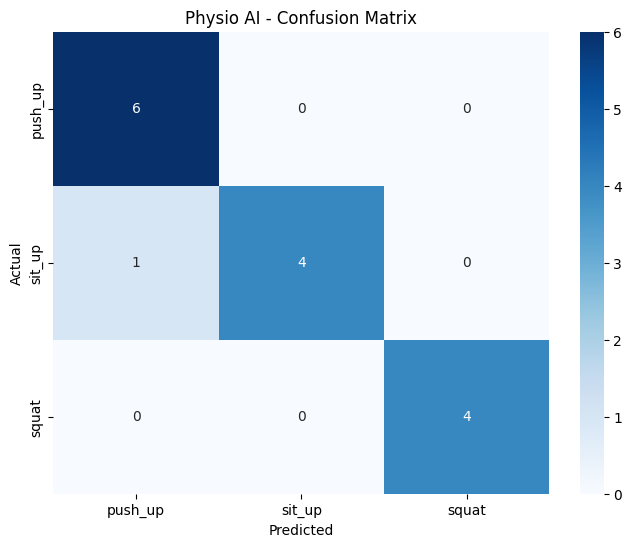

              precision    recall  f1-score   support

     push_up       0.86      1.00      0.92         6
      sit_up       1.00      0.80      0.89         5
       squat       1.00      1.00      1.00         4

    accuracy                           0.93        15
   macro avg       0.95      0.93      0.94        15
weighted avg       0.94      0.93      0.93        15



In [74]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Test data par prediction karein
yhat = lstm.predict(X_test)
ytrue = np.argmax(y_test_encoded, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

# 2. Confusion Matrix banayein
cm = confusion_matrix(ytrue, yhat)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=actions, yticklabels=actions, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Physio AI - Confusion Matrix')
plt.show()

# 3. Detailed Report
print(classification_report(ytrue, yhat, target_names=actions))

In [ ]:
%pip install seaborn

In [76]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional, Flatten, Permute, multiply
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint
import time
import os

# 1. Attention Block
def attention_block(inputs, time_steps):
    a = Permute((2, 1))(inputs)
    a = Dense(time_steps, activation='softmax')(a)
    a_probs = Permute((2, 1), name='attention_vec')(a)
    output_attention_mul = multiply([inputs, a_probs], name='attention_mul') 
    return output_attention_mul

# 2. Model Architecture
HIDDEN_UNITS = 128
inputs = Input(shape=(30, 132))

lstm_out = Bidirectional(LSTM(HIDDEN_UNITS, return_sequences=True))(inputs)
attention_mul = attention_block(lstm_out, 30)
attention_mul = Flatten()(attention_mul)

x = Dense(HIDDEN_UNITS, activation='relu')(attention_mul)
x = Dropout(0.5)(x)
x = Dense(len(actions), activation='softmax')(x)

AttnLSTM = Model(inputs=[inputs], outputs=x)

# 3. Compile & Train
AttnLSTM.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

# Logging setup
NAME = f"PhysioAI-AttnLSTM-{int(time.time())}"
log_dir = os.path.join(os.getcwd(), 'logs', NAME)
tb_callback = TensorBoard(log_dir=log_dir)

# Start Fit
history_attn = AttnLSTM.fit(
    X_train, 
    y_train_encoded, 
    batch_size=8, 
    epochs=500, 
    validation_data=(X_val, y_val_encoded), 
    callbacks=[tb_callback, es_callback, lr_callback], # Apne callbacks add karein
    verbose=1
)

Epoch 1/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - categorical_accuracy: 0.5182 - loss: 1.0184 - val_categorical_accuracy: 0.6500 - val_loss: 0.8106 - learning_rate: 0.0010
Epoch 2/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - categorical_accuracy: 0.7000 - loss: 0.6656 - val_categorical_accuracy: 0.8000 - val_loss: 0.5266 - learning_rate: 0.0010
Epoch 3/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - categorical_accuracy: 0.7909 - loss: 0.5316 - val_categorical_accuracy: 0.8000 - val_loss: 0.4239 - learning_rate: 0.0010
Epoch 4/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - categorical_accuracy: 0.8545 - loss: 0.2534 - val_categorical_accuracy: 0.9000 - val_loss: 0.2689 - learning_rate: 0.0010
Epoch 5/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - categorical_accuracy: 0.9364 - loss: 0.1774 - val_categorical_accuracy: 0.9000 - val_loss: 0.2728 - learning_rate: 0.0010
Epoch 6/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - categorical_accuracy: 0.9364 - loss: 0.1549 - val_categorical_accu

In [81]:
# Updated Callbacks
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=30, # Isse model ko aur mauka milega
    verbose=1, 
    restore_best_weights=True # YE SABSE ZAROORI HAI: Ye best epoch (Epoch 9) par wapas le jayega
)

chkpt_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_attn_model.h5', 
    monitor='val_categorical_accuracy', 
    save_best_only=True, 
    mode='max',
    verbose=1
)

In [80]:
# Model evaluate karein
test_loss, test_acc = AttnLSTM.evaluate(X_test, y_test_encoded)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Confusion Matrix check karein (Same wahi code jo pehle use kiya tha)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - categorical_accuracy: 0.5333 - loss: 0.8295
Test Accuracy: 53.33%


In [84]:
import tensorflow as tf
from tensorflow.keras.models import load_model

# Aapka 93% accuracy wala model load ho raha hai
model_path = r'D:\physio_ai_project\Experiments_notebook\best_physio_model.h5'
model = load_model(model_path)

print("✅ LSTM Model (93% Acc) Successfully Loaded!")

✅ LSTM Model (93% Acc) Successfully Loaded!


✅ 93% Accuracy Model Loaded Successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


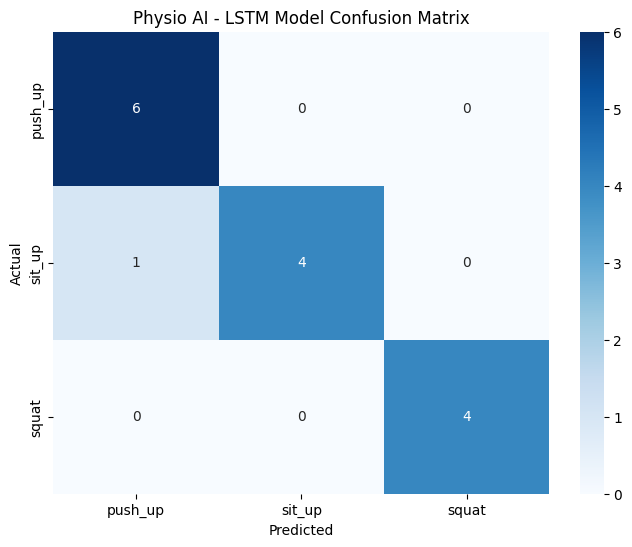

              precision    recall  f1-score   support

     push_up       0.86      1.00      0.92         6
      sit_up       1.00      0.80      0.89         5
       squat       1.00      1.00      1.00         4

    accuracy                           0.93        15
   macro avg       0.95      0.93      0.94        15
weighted avg       0.94      0.93      0.93        15



In [94]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Model Path (Raw string use karein Windows paths ke liye)
model_path = r'D:\physio_ai_project\Experiments_notebook\best_physio_model.h5'

# Model Load karein
lstm_model = load_model(model_path)
print("✅ 93% Accuracy Model Loaded Successfully!")

# 1. Test data par prediction karein
# Ensure karein ki X_test aur y_test_encoded memory mein hain
yhat_probs = lstm_model.predict(X_test)
ytrue = np.argmax(y_test_encoded, axis=1).tolist()
yhat = np.argmax(yhat_probs, axis=1).tolist()

# 2. Confusion Matrix banayein
cm = confusion_matrix(ytrue, yhat)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=actions, yticklabels=actions, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Physio AI - LSTM Model Confusion Matrix')
plt.show()

# 3. Detailed Report
print(classification_report(ytrue, yhat, target_names=actions))

In [95]:
import numpy as np
import cv2

# Global counters for your specific exercises
pushup_counter = 0
situp_counter = 0
squat_counter = 0

# Stage variables to track movement
pushup_stage = None
situp_stage = None
squat_stage = None

def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians*180.0/np.pi)
    return 360-angle if angle > 180.0 else angle

def get_coordinates(landmarks, mp_pose, side, joint):
    coord = getattr(mp_pose.PoseLandmark, side.upper()+"_"+joint.upper())
    return [landmarks[coord.value].x, landmarks[coord.value].y]            

def viz_joint_angle(image, angle, joint_coord):
    cv2.putText(image, str(int(angle)), 
                tuple(np.multiply(joint_coord, [640, 480]).astype(int)), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2, cv2.LINE_AA)

def count_reps(image, current_action, landmarks, mp_pose):
    global pushup_counter, situp_counter, squat_counter
    global pushup_stage, situp_stage, squat_stage
    
    # 1. PUSH-UP LOGIC (Monitor Elbow Angle)
    if current_action == 'push_up':
        shoulder = get_coordinates(landmarks, mp_pose, 'left', 'shoulder')
        elbow = get_coordinates(landmarks, mp_pose, 'left', 'elbow')
        wrist = get_coordinates(landmarks, mp_pose, 'left', 'wrist')
        angle = calculate_angle(shoulder, elbow, wrist)
        
        if angle < 90: pushup_stage = "down"
        if angle > 160 and pushup_stage == 'down':
            pushup_stage = "up"
            pushup_counter += 1
        viz_joint_angle(image, angle, elbow)
        
    # 2. SIT-UP LOGIC (Monitor Hip Angle)
    elif current_action == 'sit_up':
        shoulder = get_coordinates(landmarks, mp_pose, 'left', 'shoulder')
        hip = get_coordinates(landmarks, mp_pose, 'left', 'hip')
        knee = get_coordinates(landmarks, mp_pose, 'left', 'knee')
        angle = calculate_angle(shoulder, hip, knee)
        
        if angle < 60: situp_stage = "up"
        if angle > 110 and situp_stage == 'up':
            situp_stage = "down"
            situp_counter += 1
        viz_joint_angle(image, angle, hip)
        
    # 3. SQUAT LOGIC (Monitor Knee Angle)
    elif current_action == 'squat':
        hip = get_coordinates(landmarks, mp_pose, 'left', 'hip')
        knee = get_coordinates(landmarks, mp_pose, 'left', 'knee')
        ankle = get_coordinates(landmarks, mp_pose, 'left', 'ankle')
        angle = calculate_angle(hip, knee, ankle)
        
        if angle < 100: squat_stage = "down"
        if angle > 160 and squat_stage == 'down':
            squat_stage = "up"
            squat_counter += 1
        viz_joint_angle(image, angle, knee)

In [98]:
# Variables setup
sequence = []
threshold = 0.7 
actions = np.array(['push_up', 'sit_up', 'squat'])
colors = [(245,117,16), (117,245,16), (16,117,245)]

cap = cv2.VideoCapture(0)
# Video recording setup
fourcc = cv2.VideoWriter_fourcc(*'MJPG')
out = cv2.VideoWriter('PhysioAI_Live_Test.avi', fourcc, 20, (640, 480))

with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        image, results = mediapipe_detection(frame, pose)
        draw_landmarks(image, results)
        
        # Prediction logic  qqqq
        keypoints = extract_keypoints(results)        
        sequence.append(keypoints)      
        sequence = sequence[-30:] # standard sequence length
              
        if len(sequence) == 30:
            # Prediction using loaded lstm_model
            res = lstm_model.predict(np.expand_dims(sequence, axis=0), verbose=0)[0]           
            current_action = actions[np.argmax(res)]
            confidence = res[np.argmax(res)]
            
            if confidence < threshold: current_action = ''

            # Visualizations
            image = prob_viz(res, actions, image, colors)
            
            try:
                landmarks = results.pose_landmarks.landmark
                count_reps(image, current_action, landmarks, mp_pose)
            except: pass

            # Counters UI Bar
            cv2.rectangle(image, (0,0), (640, 45), (245, 117, 16), -1)
            cv2.putText(image, f'PUSHUPS: {pushup_counter}', (10,32), 1, 1.5, (255,255,255), 2)
            cv2.putText(image, f'SITUPS: {situp_counter}', (230,32), 1, 1.5, (255,255,255), 2)
            cv2.putText(image, f'SQUATS: {squat_counter}', (450,32), 1, 1.5, (255,255,255), 2)
         
        cv2.imshow('Physio AI - Smart Trainer', image)
        out.write(image)

        if cv2.waitKey(10) & 0xFF == ord('q'): break

cap.release()
out.release()
cv2.destroyAllWindows()

In [1]:
# test kalman filet 

In [2]:
%pip install opencv-python mediapipe filterpy numpy

     ------------------------------------ 178.0/178.0 kB 897.0 kB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110542 sha256=40edf7ed8b083a9426c58ed376c29fe3c2f08c17d4e5822c21907b6df1cb468f
  Stored in directory: c:\users\hp\appdata\local\pip\cache\wheels\bf\fa\58\76f71c79fa4d8bfb711d0e440cf81261adf35773baf0935306
Successfully built filterpy
Note: you may need to restart the kernel to use updated packages.


In [12]:
import numpy as np
import cv2
import mediapipe as mp
from filterpy.kalman import KalmanFilter
from typing import List, Tuple, Optional
import time
from dataclasses import dataclass
import warnings

# ============================================================================
# KALMAN FILTER CONFIGURATION
# ============================================================================
@dataclass
class KalmanConfig:
    PROCESS_NOISE_POS: float = 0.005  # Lowered for clinical smoothness
    PROCESS_NOISE_VEL: float = 0.05   
    MEASUREMENT_NOISE: float = 0.05   # Trust MediaPipe moderately
    INITIAL_POS_COV: float = 10.0
    INITIAL_VEL_COV: float = 1.0
    VISIBILITY_THRESHOLD: float = 0.3 # Allow filter to predict even if visibility is low
    MAX_PREDICTION_FRAMES: int = 15   # Max frames to "hallucinate" pose during occlusion
    EXPECTED_FPS: int = 30
    USE_ADAPTIVE_DT: bool = True

# ============================================================================
# FILTER LOGIC
# ============================================================================
class AxisKalmanFilter:
    def __init__(self, config: KalmanConfig, axis_name: str = "x"):
        self.config = config
        self.filter = KalmanFilter(dim_x=2, dim_z=1)
        dt = 1.0 / config.EXPECTED_FPS
        self.filter.F = np.array([[1, dt], [0, 1]])
        self.filter.H = np.array([[1, 0]])
        self.filter.Q = np.array([[config.PROCESS_NOISE_POS, 0], [0, config.PROCESS_NOISE_VEL]])
        self.filter.R = np.array([[config.MEASUREMENT_NOISE]])
        self.filter.P = np.array([[config.INITIAL_POS_COV, 0], [0, config.INITIAL_VEL_COV]])
        self.filter.x = np.array([[0], [0]])
        self.frames_without_measurement = 0
        self.is_initialized = False
        
    def update_dt(self, dt: float):
        self.filter.F[0, 1] = dt
        
    def predict_only(self) -> float:
        self.filter.predict()
        return float(self.filter.x[0, 0])
    
    def update_with_measurement(self, measurement: float, dt: float = None) -> float:
        if dt is not None: self.update_dt(dt)
        if not self.is_initialized:
            self.filter.x[0, 0] = measurement
            self.is_initialized = True
        self.filter.predict()
        self.filter.update(np.array([[measurement]]))
        self.frames_without_measurement = 0
        return float(self.filter.x[0, 0])

class ClinicalPoseKalmanFilter:
    def __init__(self, config: KalmanConfig = None):
        self.config = config or KalmanConfig()
        self.landmark_filters = []
        for i in range(33):
            self.landmark_filters.append({
                'x': AxisKalmanFilter(self.config),
                'y': AxisKalmanFilter(self.config),
                'z': AxisKalmanFilter(self.config)
            })
        self.last_frame_time = None

    def process_frame(self, mp_landmarks) -> List:
        current_time = time.time()
        dt = (current_time - self.last_frame_time) if self.last_frame_time else 1.0/self.config.EXPECTED_FPS
        dt = np.clip(dt, 0.01, 0.1)
        self.last_frame_time = current_time

        smoothed_landmarks = []
        for i in range(33):
            lm = mp_landmarks[i]
            is_visible = lm.visibility >= self.config.VISIBILITY_THRESHOLD
            
            res = {}
            for axis in ['x', 'y', 'z']:
                kf = self.landmark_filters[i][axis]
                val = getattr(lm, axis)
                if is_visible:
                    res[axis] = kf.update_with_measurement(val, dt)
                else:
                    res[axis] = kf.predict_only()
            
            # Reconstruct landmark object
            smoothed_lm = type('Landmark', (), {**res, 'visibility': lm.visibility})()
            smoothed_landmarks.append(smoothed_lm)
        return smoothed_landmarks

# ============================================================================
# MAIN EXECUTION LOOP
# ============================================================================
def run_live_test():
    # Initialize MediaPipe
    mp_pose = mp.solutions.pose
    mp_drawing = mp.solutions.drawing_utils
    pose = mp_pose.Pose(model_complexity=1, min_detection_confidence=0.5, min_tracking_confidence=0.5)
    
    # Initialize Kalman
    kalman = ClinicalPoseKalmanFilter()
    
    cap = cv2.VideoCapture(0)
    print("Starting Webcam... Press 'q' to quit.")

    while cap.isOpened():
        success, image = cap.read()
        if not success: break

        image = cv2.flip(image, 1)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        results = pose.process(image_rgb)

        if results.pose_landmarks:
            # Apply Smoothing
            smoothed_landmarks = kalman.process_frame(results.pose_landmarks.landmark)
            
            # --- Draw Comparison ---
            # 1. Draw RAW landmarks in Red
            mp_drawing.draw_landmarks(
                image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                landmark_drawing_spec=mp_drawing.DrawingSpec(color=(0, 0, 255), thickness=1, circle_radius=1)
            )
            
            # 2. Draw SMOOTHED landmarks in Green
            for lm in smoothed_landmarks:
                h, w, _ = image.shape
                cx, cy = int(lm.x * w), int(lm.y * h)
                cv2.circle(image, (cx, cy), 4, (0, 255, 0), -1)

        cv2.putText(image, "RED: Raw | GREEN: Kalman Smoothed", (10, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        cv2.imshow('Clinical Pose Analysis', image)

        if cv2.waitKey(5) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    run_live_test()

Starting Webcam... Press 'q' to quit.


In [4]:
%pip install opencv-python mediapipe numpy scipy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [10]:
import cv2
import numpy as np
import mediapipe as mp
import sys

# PipelineConfig se zaroori values copy ki gayi hain
class LiveConfig:
    NUM_LANDMARKS = 33
    BASE_FEATURES_PER_LANDMARK = 4 # x, y, z, visibility
    RELATIVE_DISTANCE_PAIRS = [(11, 12), (23, 24), (11, 23), (12, 24), (15, 17), (16, 18)]
    RELATIVE_ANGLES = [(11, 23, 25), (12, 24, 26), (11, 13, 15), (12, 14, 16)]
    TOTAL_FEATURES = 142 # 132 (Base) + 6 (Dist) + 4 (Angles)

def extract_live_features(landmarks):
    features = []
    
    # 1. Base Landmarks (132 features)
    mid_hip_x = (landmarks[23].x + landmarks[24].x) / 2
    mid_hip_y = (landmarks[23].y + landmarks[24].y) / 2
    
    for lm in landmarks:
        features.extend([
            lm.x - mid_hip_x, 
            lm.y - mid_hip_y, 
            lm.z, 
            lm.visibility
        ])
    
    # 2. Relative Distances (6 features)
    for i, j in LiveConfig.RELATIVE_DISTANCE_PAIRS:
        dx = landmarks[i].x - landmarks[j].x
        dy = landmarks[i].y - landmarks[j].y
        distances = np.sqrt(dx**2 + dy**2)
        features.append(distances)
        
    # 3. Relative Angles (4 features)
    for a_idx, b_idx, c_idx in LiveConfig.RELATIVE_ANGLES:
        ba = np.array([landmarks[a_idx].x - landmarks[b_idx].x, landmarks[a_idx].y - landmarks[b_idx].y])
        bc = np.array([landmarks[c_idx].x - landmarks[b_idx].x, landmarks[c_idx].y - landmarks[b_idx].y])
        cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-10)
        angle = np.arccos(np.clip(cosine_angle, -1.0, 1.0))
        features.append(angle)
        
    return np.array(features)

# MediaPipe Setup
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
pose = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)

cap = cv2.VideoCapture(0) # 0 is default webcam

print(f"Starting Live Stream... Feature Count: {LiveConfig.TOTAL_FEATURES}")

try:
    while cap.isOpened():
        success, frame = cap.read()
        if not success: break

        # BGR to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(frame_rgb)

        if results.pose_landmarks:
            # Features Extract karein
            current_features = extract_live_features(results.pose_landmarks.landmark)
            
            # Terminal pe print karein (Single line update for readability)
            sys.stdout.write(f"\rFeatures Detected: {len(current_features)} | First 5: {np.round(current_features[:5], 3)}")
            sys.stdout.flush()

            # Skeleton draw karein preview window ke liye
            mp_drawing.draw_landmarks(frame, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)

        cv2.imshow('MediaPipe Live Features', frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
finally:
    cap.release()
    cv2.destroyAllWindows()
    print("\nStream Stopped.")

Starting Live Stream... Feature Count: 142
Features Detected: 142 | First 5: [-0.012 -0.955 -0.961  0.998  0.008].990e-01  2.600e-02]
Stream Stopped.


In [ ]:
import cv2
import numpy as np
import mediapipe as mp
import time
import sys

class LiveConfig:
    # Feature Counts
    POSE_BASE = 132    # 33 landmarks * 4
    POSE_EXTRA = 10    # 6 distances + 4 angles
    HAND_BASE = 84     # 21 landmarks * 4 (per hand)
    TOTAL_FEATURES = POSE_BASE + POSE_EXTRA + (HAND_BASE * 2) # Total 310

class FeatureEngine:
    """Smartly extracts and normalizes features"""
    
    @staticmethod
    def get_pose_features(pose_landmarks, config):
        if not pose_landmarks: return [0.0] * (config.POSE_BASE + config.POSE_EXTRA)
        
        lm = pose_landmarks.landmark
        features = []
        # Reference point: Mid-hip
        ref_x = (lm[23].x + lm[24].x) / 2
        ref_y = (lm[23].y + lm[24].y) / 2
        
        # 1. Normalized Base Landmarks
        for i in range(33):
            features.extend([lm[i].x - ref_x, lm[i].y - ref_y, lm[i].z, lm[i].visibility])
            
        # 2. Relative Distances
        dist_pairs = [(11, 12), (23, 24), (11, 23), (12, 24), (15, 17), (16, 18)]
        for i, j in dist_pairs:
            features.append(np.linalg.norm(np.array([lm[i].x - lm[j].x, lm[i].y - lm[j].y])))
            
        # 3. Relative Angles
        angles = [(11, 23, 25), (12, 24, 26), (11, 13, 15), (12, 14, 16)]
        for a, b, c in angles:
            v1 = np.array([lm[a].x - lm[b].x, lm[a].y - lm[b].y])
            v2 = np.array([lm[c].x - lm[b].x, lm[c].y - lm[b].y])
            cos = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-10)
            features.append(np.arccos(np.clip(cos, -1.0, 1.0)))
            
        return features

    @staticmethod
    def get_hand_features(hand_landmarks):
        if not hand_landmarks: return [0.0] * 84
        
        lm = hand_landmarks.landmark
        features = []
        # Reference point: Wrist (index 0)
        wrist_x, wrist_y, wrist_z = lm[0].x, lm[0].y, lm[0].z
        
        for i in range(21):
            # Normalizing finger movements relative to the wrist
            features.extend([lm[i].x - wrist_x, lm[i].y - wrist_y, lm[i].z - wrist_z, 1.0])
        return features

# --- Setup MediaPipe ---
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils
# model_complexity 2 (Heavy but precise)
holistic = mp_holistic.Holistic(model_complexity=2, min_detection_confidence=0.5, min_tracking_confidence=0.5)

# --- Start Webcam ---
cap = cv2.VideoCapture(0)
p_time = 0

print(f"--- Physio-AI Pro Initialized (Features: {LiveConfig.TOTAL_FEATURES}) ---")

try:
    while cap.isOpened():
        success, frame = cap.read()
        if not success: break
        
        # Processing
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = holistic.process(frame_rgb)
        
        # Feature Extraction
        pose_feats = FeatureEngine.get_pose_features(results.pose_landmarks, LiveConfig)
        lh_feats = FeatureEngine.get_hand_features(results.left_hand_landmarks)
        rh_feats = FeatureEngine.get_hand_features(results.right_hand_landmarks)
        
        final_vector = np.array(pose_feats + lh_feats + rh_feats)

        # UI & Feedback
        c_time = time.time()
        fps = 1 / (c_time - p_time)
        p_time = c_time

        # Visual Overlay
        cv2.putText(frame, f"FPS: {int(fps)}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2.putText(frame, f"Features: {len(final_vector)}", (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 1)

        # Draw with custom styles
        if results.pose_landmarks:
            mp_drawing.draw_landmarks(frame, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                                    mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=2))
        if results.left_hand_landmarks:
            mp_drawing.draw_landmarks(frame, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS)
        if results.right_hand_landmarks:
            mp_drawing.draw_landmarks(frame, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)

        # Print to Terminal
        sys.stdout.write(f"\r[STATUS] Vector Shape: {final_vector.shape} | LH: {results.left_hand_landmarks is not None} | RH: {results.right_hand_landmarks is not None}")
        sys.stdout.flush()

        cv2.imshow('Physio-AI Pro Tracker', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'): break

finally:
    cap.release()
    cv2.destroyAllWindows()

--- Physio-AI Pro Initialized (Features: 310) ---
[STATUS] Vector Shape: (310,) | LH: False | RH: False

In [ ]:
print("Physio AI Pro Live Feature Extraction Module Loaded Successfully!")